In [1]:
# !pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, recall_score, confusion_matrix, average_precision_score, precision_recall_curve, roc_auc_score, cohen_kappa_score
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.inspection import permutation_importance

## Load Data

In [3]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
# df = pd.read_csv('/kaggle/input/malnutrition/ch.csv')
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,status,province_Gandaki Province,province_Karnali Province,province_Province 1,province_Province 2,province_Province 5,province_Sudoorpaschim Province
0,1.0,-1.066081,0,0,0,1,2.0,1,1.0,1,0,0,1,0,0,0
1,3.0,0.434428,0,1,0,1,2.0,1,1.0,1,0,0,1,0,0,0


### Train-test split

In [4]:
X = df.drop(columns=['status'])
y = df['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [5]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2413})
After SMOTE:  Counter({0: 2828, 1: 2828})


# K-nearest Neighborhood

### Simple model

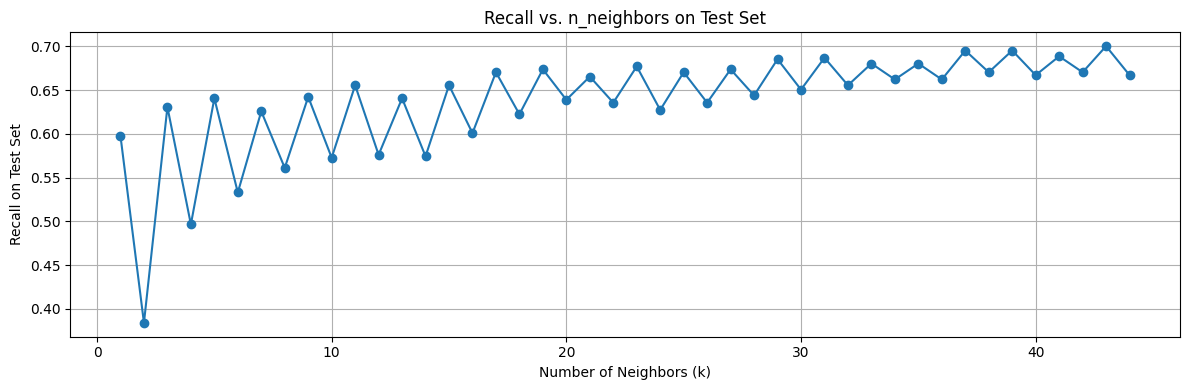

In [6]:
recalls = []

for k in range(1, 45):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sm, y_train_sm)
    y_pred = knn.predict(X_test)
    recalls.append(recall_score(y_test, y_pred))

plt.figure(figsize=(12, 4))
plt.plot(range(1, 45), recalls, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Recall on Test Set")
plt.title("Recall vs. n_neighbors on Test Set")
plt.grid()
plt.tight_layout()
plt.show()

In [7]:
knn = KNeighborsClassifier()
knn.fit(X_train_sm, y_train_sm)
y_pred = knn.predict(X_test)
print(f'Classification Report: \n{classification_report(y_test, y_pred, digits = 3)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0      0.681     0.655     0.668       707
           1      0.613     0.641     0.627       604

    accuracy                          0.648      1311
   macro avg      0.647     0.648     0.647      1311
weighted avg      0.650     0.648     0.649      1311




In [8]:
y_probas = knn.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.6302917997794799


# Hyperparameter Tuning

In [9]:
params = {'n_neighbors':range(1, 36), 
          'weights':['uniform', 'distance'], 
          'metric': ['euclidean', 'manhattan', 'minkowski']}

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=params,
    cv=10,
    scoring='recall',
    verbose=1,
    n_jobs=2
)

grid_search.fit(X_train_sm, y_train_sm)

Fitting 10 folds for each of 210 candidates, totalling 2100 fits


GridSearchCV(cv=10, estimator=KNeighborsClassifier(), n_jobs=2,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': range(1, 36),
                         'weights': ['uniform', 'distance']},
             scoring='recall', verbose=1)

In [10]:
print("Best Parameters:", grid_search.best_params_)
print(f"Best cross-validation recall score: {grid_search.best_score_:.3f}")

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 28, 'weights': 'distance'}
Best cross-validation recall score: 0.716


In [11]:
knn_tune = grid_search.best_estimator_
y_pred_tune = knn_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred_tune, digits= 3))

Classification Report:
               precision    recall  f1-score   support

           0      0.693     0.673     0.683       707
           1      0.630     0.651     0.640       604

    accuracy                          0.663      1311
   macro avg      0.661     0.662     0.661      1311
weighted avg      0.664     0.663     0.663      1311



In [12]:
y_probas_tune = knn_tune.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas_tune)}')

Average Precision: 0.6681023391427872


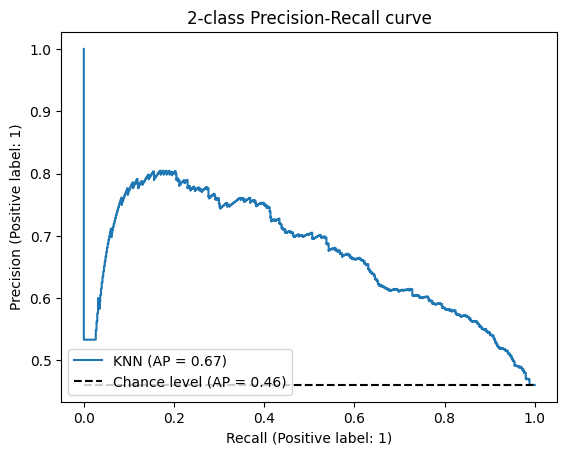

In [13]:
display = PrecisionRecallDisplay.from_estimator(
    knn_tune,   # trained model
    X_test,        # Test features
    y_test,        # True labels
    name="KNN",
    plot_chance_level=True,
)
display.ax_.set_title("2-class Precision-Recall curve")
plt.show()

### Recall score on train set

In [14]:
# Recall on base model
y_train_pred = knn.predict(X_train_sm)
train_recall = recall_score(y_train_sm, y_train_pred)
print(f"Recall on Training set (Base Model): {train_recall:.3f}")

# Recall on tune tune model
y_train_pred = knn_tune.predict(X_train_sm)
train_recall = recall_score(y_train_sm, y_train_pred)
print(f"Recall on Training set (Tune Model): {train_recall:.3f}")

Recall on Training set (Base Model): 0.796
Recall on Training set (Tune Model): 0.986


### AUC score

In [24]:
auc = roc_auc_score(y_test, y_probas)
print(f"AUC: {auc:.3f}")

auc_tune = roc_auc_score(y_test, y_probas_tune)
print(f"AUC: {auc_tune:.3f}")

AUC: 0.696
AUC: 0.730


### Cohen's Kappa

In [23]:
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.3f}")

kappa_tune = cohen_kappa_score(y_test, y_pred_tune)
print(f"Cohen's Kappa: {kappa_tune:.3f}")

Cohen's Kappa: 0.295
Cohen's Kappa: 0.323


### Confusion matrix

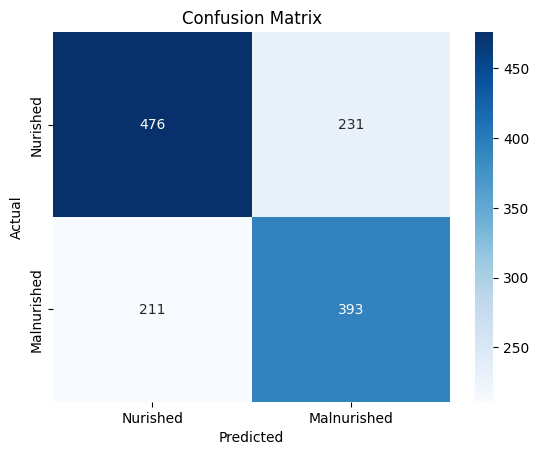

In [17]:
cm = confusion_matrix(y_test, y_pred_tune)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature importance

In [18]:
# Compute permutation importance using recall as the scoring metric
result = permutation_importance(
    knn_tune,         # Trained KNN model
    X_test,           # Test features
    y_test,           # True labels
    scoring='recall',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create DataFrame with actual and absolute mean importance
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean Importance': result.importances_mean,
    'Abs Mean Importance': np.abs(result.importances_mean),
    'Std Dev': result.importances_std
})

# Sort by absolute importance descending
importance_df = importance_df.sort_values(by='Abs Mean Importance', ascending=False)

# Show table
print(importance_df)


                            Feature  Mean Importance  Abs Mean Importance  \
1                      child_weight         0.095861             0.095861   
8                      wealth_index         0.022848             0.022848   
3                fever_last_2_weeks        -0.013907             0.013907   
12              province_Province 2         0.011258             0.011258   
13              province_Province 5         0.008940             0.008940   
11              province_Province 1        -0.007947             0.007947   
10        province_Karnali Province         0.007285             0.007285   
6                  mother_education        -0.007285             0.007285   
2            diarrhoea_last_2_weeks        -0.004470             0.004470   
0                         child_age         0.003477             0.003477   
9         province_Gandaki Province         0.002152             0.002152   
14  province_Sudoorpaschim Province        -0.001987             0.001987   

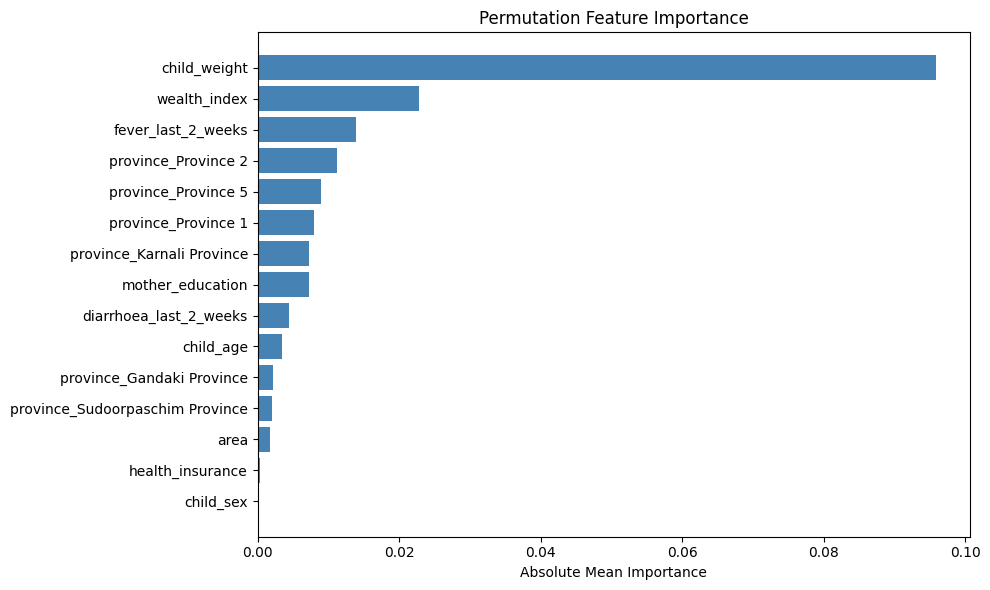

In [19]:
# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Abs Mean Importance'], color='steelblue')
plt.xlabel("Absolute Mean Importance")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Additional

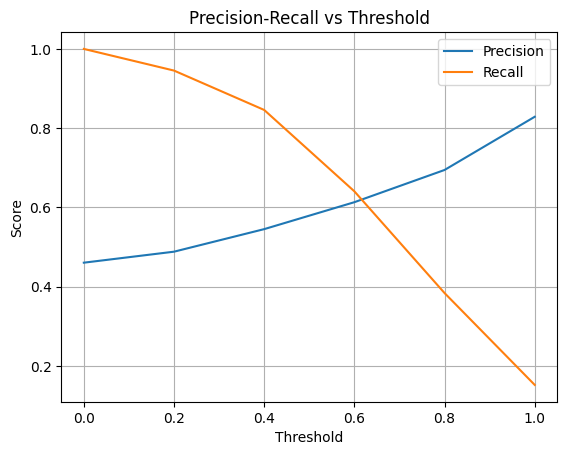

In [20]:
y_probas_tune = knn_tune.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [21]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom, digtis = 3)}\n')

TypeError: got an unexpected keyword argument 'digtis'